# Regresión: predicción del precio de automóviles

In [70]:
# Importación de librerías

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import TransformedTargetRegressor

RANDOM_STATE = 42

pd.set_option('display.max_columns', 120)

# Fuente del dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data'

columns = [
    'symboling','normalized-losses','make','fuel-type','aspiration','num-of-doors','body-style',
    'drive-wheels','engine-location','wheel-base','length','width','height','curb-weight',
    'engine-type','num-of-cylinders','engine-size','fuel-system','bore','stroke','compression-ratio',
    'horsepower','peak-rpm','city-mpg','highway-mpg','price'
]


## (1) Importación + comprobaciones iniciales

Antes de transformar nada, comprobamos **cómo vienen los datos**:

- Mostramos 5 filas "raw" del fichero original.

- Contamos cuántos valores`?` (missing en origen) aparecen por columna.

- Convertimos`?` →`NaN` y verificamos tipos de datos y nulos del target.


In [71]:
# 1.1) Lectura "raw" (sin convertir '?')

df_raw = pd.read_csv(url, header=None, names=columns, dtype=str)
display(df_raw.head())

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.60,168.80,64.10,48.80,2548,dohc,four,130,mpfi,3.47,2.68,9.00,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.60,168.80,64.10,48.80,2548,dohc,four,130,mpfi,3.47,2.68,9.00,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.50,171.20,65.50,52.40,2823,ohcv,six,152,mpfi,2.68,3.47,9.00,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.80,176.60,66.20,54.30,2337,ohc,four,109,mpfi,3.19,3.40,10.00,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.40,176.60,66.40,54.30,2824,ohc,five,136,mpfi,3.19,3.40,8.00,115,5500,18,22,17450


- En la vista “raw” se observa que los missing vienen como el carácter **`?`** (no como`NaN`). Por eso primero los cuantifico y luego los convierto a`NaN` para poder imputar.

In [72]:
# 1.2) Conteo de '?' por columna (missing en origen)

qmark_counts = (df_raw == '?').sum().sort_values(ascending=False)
display(qmark_counts.head(10))

normalized-losses    41
stroke                4
price                 4
bore                  4
horsepower            2
peak-rpm              2
num-of-doors          2
symboling             0
fuel-type             0
make                  0
dtype: int64

- Esta tabla confirma que hay missing reales y en qué columnas se concentran (por ejemplo,`normalized-losses` tiene muchos`?`). Esto justifica usar imputación en el preprocesado.

In [73]:
# 1.3) Parseo: convertir '?' -> NaN y separar X / y

df = pd.read_csv(url, header=None, names=columns, na_values='?')

y = pd.to_numeric(df['price'], errors='coerce')
X = df.drop(columns=['price']).copy()

print('Filas:', X.shape[0], 'Columnas:', X.shape[1])
print('Target nulos (price):', int(y.isna().sum()))

# Vista rápida (4 filas) tras convertir '?' -> NaN y separar X/y
display(pd.concat([X.head(4), y.head(4).rename('price')], axis=1))

Filas: 205 Columnas: 25
Target nulos (price): 4


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0


- Al convertir`?` a`NaN`, ya podemos imputar con`SimpleImputer`.
- Como`price` tiene nulos, esas filas se eliminan antes del entrenamiento (no podemos aprender con el target desconocido).

- La separación entre columnas **numéricas** y **categóricas** se comprueba justo después del`train_test_split` (más adelante), para definir el preprocesado usando solo`train` y evitar *data leakage*.

## (1) Preprocesado de los datos

En este apartado se cubren explícitamente:

- Manejar datos missing

- Manejar datos categóricos

- Evitar trampa de las variables dummy

- Separar datos en entrenamiento y test

- Estandarizar/normalizar

Decisiones:

- **Numéricas**: imputación por mediana + estandarización.

- **Categóricas**: imputación por moda + one-hot con`drop='first'`.


In [74]:
# 2.1) Limpieza del target: eliminar filas con price nulo

n_before = len(y)
mask = y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].copy()
n_after = len(y)
print('Filas eliminadas por target nulo:', n_before - n_after)
print('Filas restantes:', n_after)


Filas eliminadas por target nulo: 4
Filas restantes: 201


- Eliminamos esas filas porque en regresión no podemos entrenar si`price` está vacío. Así el entrenamiento y la evaluación quedan bien definidos.

In [75]:
# 2.2) Separación train/test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print('Train:', X_train.shape, 'Test:', X_test.shape)

# Nota: X (features) y y (target) SIEMPRE tienen contenidos distintos por definición.
# Lo importante es que estén alineados por índice (mismas filas).

# Vista rápida (4 filas) de train: X junto con su y correspondiente
print('Primeras 4 filas de train (X y y alineados):')
idx_tr = X_train.head(4).index
display(pd.concat([X_train.loc[idx_tr], y_train.loc[idx_tr].rename('price')], axis=1))

# Vista rápida (4 filas) de test: X junto con su y correspondiente
print('Primeras 4 filas de test (X y y alineados):')
idx_te = X_test.head(4).index
display(pd.concat([X_test.loc[idx_te], y_test.loc[idx_te].rename('price')], axis=1))



Train: (160, 25) Test: (41, 25)
Primeras 4 filas de train (X y y alineados):


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
202,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,six,173,mpfi,3.58,2.87,8.8,134.0,5500.0,18,23,21485.0
39,0,85.0,honda,gas,std,four,sedan,fwd,front,96.5,175.4,65.2,54.1,2304,ohc,four,110,1bbl,3.15,3.58,9.0,86.0,5800.0,27,33,8845.0
25,1,148.0,dodge,gas,std,four,sedan,fwd,front,93.7,157.3,63.8,50.6,1989,ohc,four,90,2bbl,2.97,3.23,9.4,68.0,5500.0,31,38,6692.0
125,3,186.0,porsche,gas,std,two,hatchback,rwd,front,94.5,168.9,68.3,50.2,2778,ohc,four,151,mpfi,3.94,3.11,9.5,143.0,5500.0,19,27,22018.0


Primeras 4 filas de test (X y y alineados):


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
98,2,168.0,nissan,gas,std,two,hardtop,fwd,front,95.1,162.4,63.8,53.3,2008,ohc,four,97,2bbl,3.15,3.29,9.4,69.0,5200.0,31,37,8249.0
16,0,NaN,bmw,gas,std,two,sedan,rwd,front,103.5,193.8,67.9,53.7,3380,ohc,six,209,mpfi,3.62,3.39,8.0,182.0,5400.0,16,22,41315.0
31,2,137.0,honda,gas,std,two,hatchback,fwd,front,86.6,144.6,63.9,50.8,1819,ohc,four,92,1bbl,2.91,3.41,9.2,76.0,6000.0,31,38,6855.0
162,0,91.0,toyota,gas,std,four,sedan,fwd,front,95.7,166.3,64.4,52.8,2140,ohc,four,98,2bbl,3.19,3.03,9.0,70.0,4800.0,28,34,9258.0


- Separamos datos para evaluar generalización: entreno con`train` y reporto métricas en`test`.

In [76]:
# 2.3) Detectar columnas numéricas y categóricas

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]
print('Num cols:', len(num_cols), 'Cat cols:', len(cat_cols))
print('Ejemplos numéricas:', num_cols[:8])
print('Ejemplos categóricas:', cat_cols[:8])

# Vista rápida (4 filas) separando numéricas y categóricas
if len(num_cols) > 0:
    display(X_train[num_cols].head(4))
if len(cat_cols) > 0:
    display(X_train[cat_cols].head(4))

Num cols: 15 Cat cols: 10
Ejemplos numéricas: ['symboling', 'normalized-losses', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size']
Ejemplos categóricas: ['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'engine-type']


,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
202,-1,95.0,109.1,188.8,68.9,55.5,3012,173,3.58,2.87,8.8,134.0,5500.0,18,23
39,0,85.0,96.5,175.4,65.2,54.1,2304,110,3.15,3.58,9.0,86.0,5800.0,27,33
25,1,148.0,93.7,157.3,63.8,50.6,1989,90,2.97,3.23,9.4,68.0,5500.0,31,38
125,3,186.0,94.5,168.9,68.3,50.2,2778,151,3.94,3.11,9.5,143.0,5500.0,19,27


,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system
202,volvo,gas,std,four,sedan,rwd,front,ohcv,six,mpfi
39,honda,gas,std,four,sedan,fwd,front,ohc,four,1bbl
25,dodge,gas,std,four,sedan,fwd,front,ohc,four,2bbl
125,porsche,gas,std,two,hatchback,rwd,front,ohc,four,mpfi


- Esto confirma que necesito dos pipelines distintos: uno para numéricas (imputar+escalar) y otro para categóricas (imputar+one-hot).

In [77]:
# 2.4) Definir el preprocesado (imputación + escalado + one-hot)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ],
    remainder='drop'
)

display(preprocess)

# Mini-demo: efecto del preprocesado (sin imprimir todas las columnas)
preprocess.fit(X_train)
Xt_train = preprocess.transform(X_train)
print('Shape original X_train:', X_train.shape)
print('Shape tras preprocess (one-hot + escalado):', Xt_train.shape)

# (Opcional) nombres de features generadas tras one-hot
try:
    fn = preprocess.get_feature_names_out()
    print('Ejemplo de nombres de features (primeras 20):')
    print(list(fn[:20]))
    
    # Mostrar explícitamente algunas columnas one-hot (0/1) en 4 filas
    idx_cat = [i for i, name in enumerate(fn) if str(name).startswith('cat__')]
    if len(idx_cat) > 0:
        idx_show = idx_cat[:12]  # solo unas pocas para que sea legible
        X4 = Xt_train[:4, idx_show]
        if hasattr(X4, 'toarray'):
            X4 = X4.toarray()
        df_onehot_preview = pd.DataFrame(X4, columns=[str(fn[i]) for i in idx_show])
        print('Preview one-hot (0/1) — 4 filas, 12 columnas:')
        display(df_onehot_preview)
    else:
        print('No hay columnas categóricas (cat__) para one-hot en este split.')
except Exception as e:
    print('No se pudieron obtener nombres de features:', type(e).__name__, str(e))

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['symboling', 'normalized-losses',
                                  'wheel-base', 'length', 'width', 'height',
                                  'curb-weight', 'engine-size', 'bore',
                                  'stroke', 'compression-ratio', 'horsepower',
                                  'peak-rpm', 'city-mpg', 'highway-mpg']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['make', 'fuel-type', 'aspiration',
                                  'num-of-doors', 'body-style', 'drive-wheels',
                                  'engine-location', 'engine-type',
                                  'num-of-cylinders', 'fuel-system'])])

Shape original X_train: (160, 25)
Shape tras preprocess (one-hot + escalado): (160, 64)
Ejemplo de nombres de features (primeras 20):
['num__symboling', 'num__normalized-losses', 'num__wheel-base', 'num__length', 'num__width', 'num__height', 'num__curb-weight', 'num__engine-size', 'num__bore', 'num__stroke', 'num__compression-ratio', 'num__horsepower', 'num__peak-rpm', 'num__city-mpg', 'num__highway-mpg', 'cat__make_audi', 'cat__make_bmw', 'cat__make_chevrolet', 'cat__make_dodge', 'cat__make_honda']
Preview one-hot (0/1) — 4 filas, 12 columnas:


,cat__make_audi,cat__make_bmw,cat__make_chevrolet,cat__make_dodge,cat__make_honda,cat__make_isuzu,cat__make_jaguar,cat__make_mazda,cat__make_mercedes-benz,cat__make_mercury,cat__make_mitsubishi,cat__make_nissan
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


- Numéricas: mediana +`StandardScaler` para que la escala no perjudique a modelos sensibles (p.ej. SVR).
- Categóricas: moda +`OneHotEncoder` con`drop='first'` para evitar multicolinealidad perfecta (trampa de dummies).

In [78]:
# 2.5) Missing rate en train (top 10)

missing_rate = X_train.isna().mean().sort_values(ascending=False)
display(missing_rate.head(10))

normalized-losses    0.17500
bore                 0.01875
stroke               0.01875
peak-rpm             0.01250
horsepower           0.01250
num-of-doors         0.00625
symboling            0.00000
fuel-type            0.00000
make                 0.00000
engine-location      0.00000
dtype: float64

- Esta tabla muestra en qué variables hay más missing. Aunque luego imputamos todas las columnas con missing, aquí se ve por qué es imprescindible hacerlo.

## (0.5) EDA básico

Se realiza un EDA básico centrado en:

- Distribución de la variable objetivo

- Correlaciones entre variables numéricas

- Pairplot de algunas variables representativas

- Conclusiones


(Nota de estructura) Igual que en EDA, en Preprocesado y Modelos verás que cada salida de código tiene su celda de explicación justo debajo.

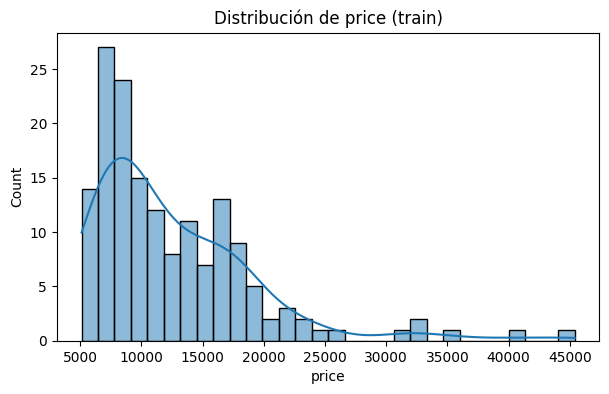

In [79]:
# 2.1) Distribución del target (precio)

plt.figure(figsize=(7,4))
sns.histplot(y_train, bins=30, kde=True)
plt.title('Distribución de price (train)')
plt.xlabel('price')
plt.show()

- El precio (`price`) presenta asimetría positiva (cola a la derecha), por lo que una transformación logarítmica (`log1p`) puede ayudar a estabilizar la varianza.

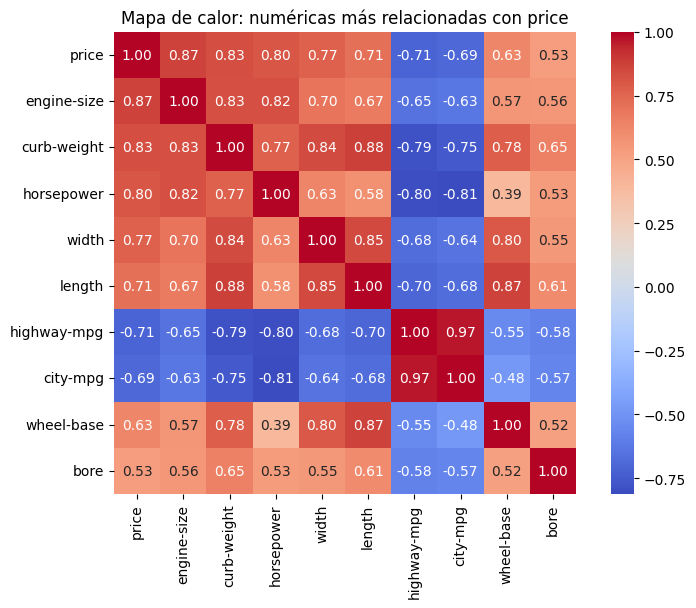

In [80]:
# 2.2) Correlaciones (solo numéricas)

num_df = X_train[num_cols].copy()
num_df['price'] = y_train.values
corr = num_df.corr(numeric_only=True)
top = corr['price'].abs().sort_values(ascending=False).head(10).index

plt.figure(figsize=(9,6))
sns.heatmap(corr.loc[top, top], annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Mapa de calor: numéricas más relacionadas con price')
plt.show()

- Variables técnicas como **`engine-size`**, **`curb-weight`** y **`horsepower`** muestran alta correlación con`price` (según el mapa de calor), lo que respalda su valor predictivo.

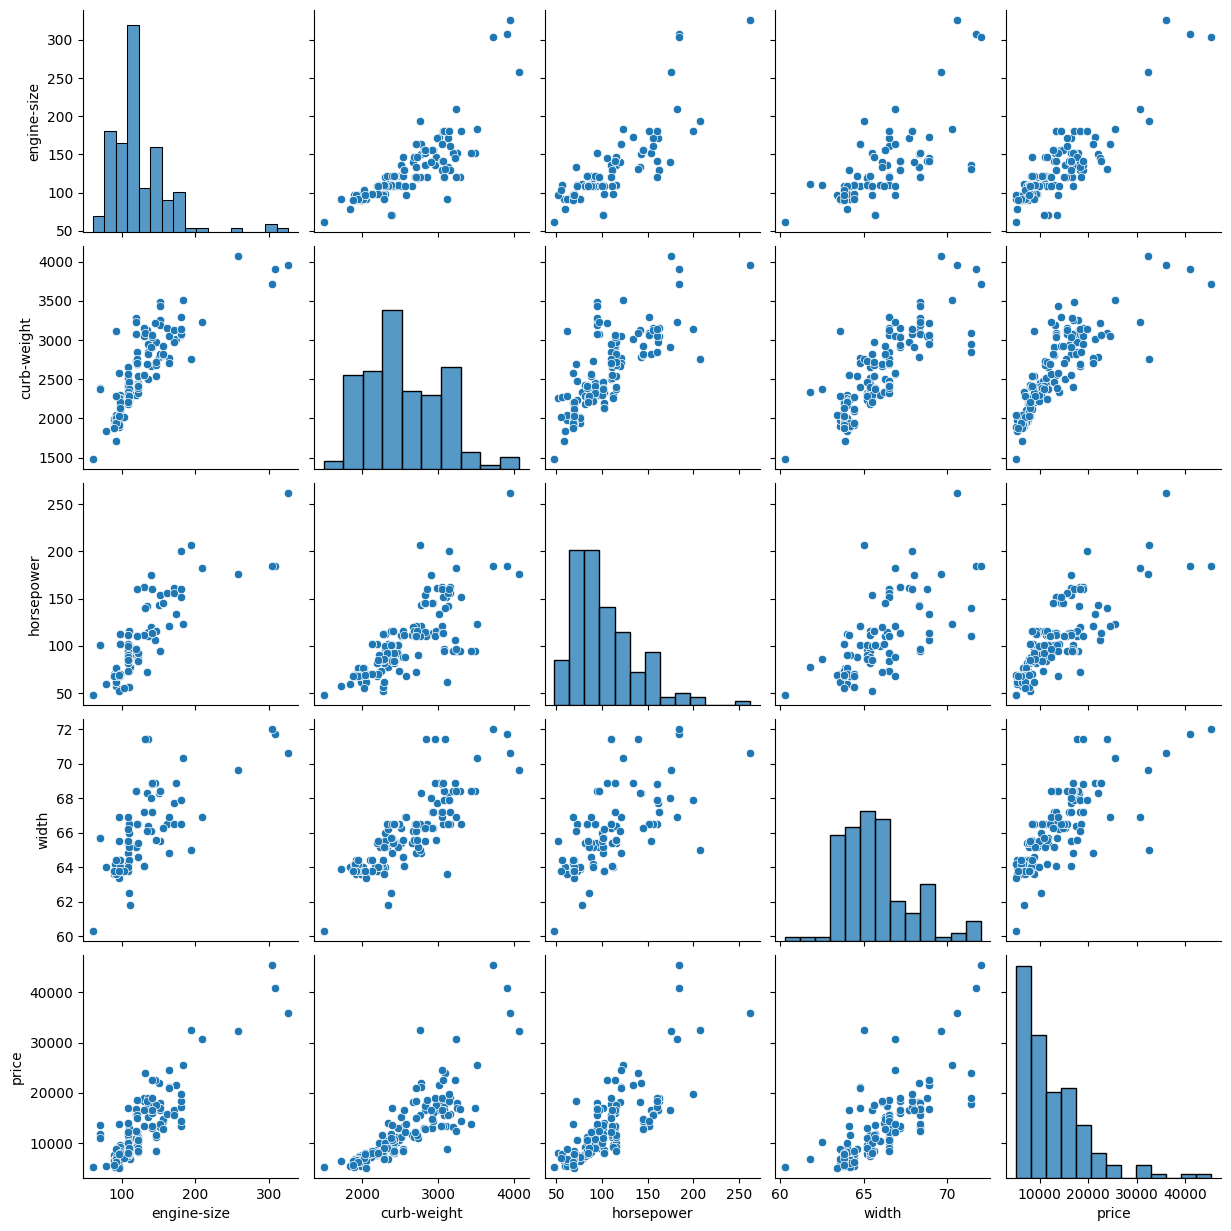

In [81]:
# 2.3) Pairplot (pequeño)

pair_cols = [c for c in top if c != 'price'][:4] + ['price']
sns.pairplot(num_df[pair_cols].dropna())
plt.show()

- Se aprecian relaciones no estrictamente lineales y posibles interacciones entre variables ⇒ tiene sentido probar modelos no lineales como **SVR**, **árboles** y **bosques aleatorios**.

## (1) Modelos de regresión y predicciones

Entrenaremos y compararemos:

- Regresión lineal (OLS) como baseline
- Regresión lineal con regularización **Ridge** (baseline lineal más estable)
- Regresión polinomial (grado 2 en numéricas) + Ridge
- SVR (Máquinas de soporte vectorial)
- Árbol de decisión
- Bosque aleatorio

(Estructura) Igual que antes: primero ejecuto un bloque de código y justo debajo dejo su interpretación, para que el guion y lo que se ve en pantalla no se contradigan.

In [82]:
# 3.1) Funciones de evaluación (métricas)

def adjusted_r2(r2: float, n: int, p: int) -> float:
    # R2 ajustada solo tiene sentido si p < n-1 (si no, la fórmula no está definida).
    if n <= p + 1:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


def _count_effective_features(pipe: Pipeline, X_sample: pd.DataFrame) -> int:
    # Nº de columnas *después* del preprocesado (one-hot, escalado, etc.).
    Xt = pipe.named_steps['preprocess'].transform(X_sample)
    return Xt.shape[1]


def evaluate_regressor(name: str, model, X_train, y_train, X_test, y_test, *, preprocesser=None):
    preprocesser = preprocesser if preprocesser is not None else preprocess
    pipe = Pipeline(steps=[('preprocess', preprocesser), ('model', model)])
    pipe.fit(X_train, y_train)

    y_pred_train = pipe.predict(X_train)
    y_pred_test = pipe.predict(X_test)

    mse_train = mean_squared_error(y_train, y_pred_train)
    mae_train = mean_absolute_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)

    mse_test = mean_squared_error(y_test, y_pred_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)

    # Nota: R2 ajustada es principalmente interpretable para modelos lineales.
    p_features = np.nan
    adj_r2_test = np.nan
    if isinstance(model, (LinearRegression, Ridge)):
        try:
            p_features = int(_count_effective_features(pipe, X_train))
        except Exception:
            p_features = np.nan
        if isinstance(p_features, (int, np.integer)) and X_test.shape[0] > p_features + 1:
            adj_r2_test = adjusted_r2(r2_test, n=X_test.shape[0], p=p_features)

    return {
        'model': name,
        'mse_train': mse_train,
        'mae_train': mae_train,
        'r2_train': r2_train,
        'mse_test': mse_test,
        'mae_test': mae_test,
        'r2_test': r2_test,
        'adj_r2_test': adj_r2_test,
        'y_pred_test': y_pred_test,
        'y_pred_train': y_pred_train,
        'pipeline': pipe,
        'p_features': p_features,
    }

- Aquí defino una función común de evaluación para que **todos los modelos** se midan igual (MSE/MAE/R² en train y test).
- La $R^2$ ajustada solo la uso cuando tiene sentido (principalmente en modelos lineales y si $p < n-1$), para evitar columnas`NaN` engañosas.

In [83]:
# 3.2) Preprocesado para el modelo polinomial (solo numéricas)

numeric_poly = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

categorical_basic = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocess_poly = ColumnTransformer(
    transformers=[
        ('num', numeric_poly, num_cols),
        ('cat', categorical_basic, cat_cols)
    ],
    remainder='drop'
)

display(preprocess_poly)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler()),
                                                 ('poly',
                                                  PolynomialFeatures(include_bias=False))]),
                                 ['symboling', 'normalized-losses',
                                  'wheel-base', 'length', 'width', 'height',
                                  'curb-weight', 'engine-size', 'bore',
                                  'stroke', 'compression-ratio', 'horsepower',
                                  'peak-rpm', 'city-mpg', 'highway-mpg']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['make', 'fuel-type', 'aspiration',
                                  'num-of-doors', 'body-style', 'drive-wheels',
                                  'engine-location', 'engine-type',
                                  'num-of-cylinders', 'fuel-system'])])

- En este dataset, aplicar polinomios a dummies puede explotar el nº de columnas. Por eso el polinomio se aplica **solo a numéricas** y las categóricas se quedan en one-hot normal.

In [84]:
# 3.3) Entrenamiento y comparación de modelos

results = []

# Extra: baselines lineales SOLO con variables numéricas (para que R2 ajustada sea definible)
preprocess_num_only = ColumnTransformer(
    transformers=[('num', numeric_transformer, num_cols)],
    remainder='drop'
)
results.append(evaluate_regressor('LinearRegression (num only)', LinearRegression(), X_train, y_train, X_test, y_test, preprocesser=preprocess_num_only))
results.append(evaluate_regressor('Ridge(alpha=10) (num only)', Ridge(alpha=10.0), X_train, y_train, X_test, y_test, preprocesser=preprocess_num_only))

# Baselines lineales
results.append(evaluate_regressor('LinearRegression (OLS)', LinearRegression(), X_train, y_train, X_test, y_test))
results.append(evaluate_regressor('Ridge(alpha=10)', Ridge(alpha=10.0), X_train, y_train, X_test, y_test))

# Polinomial (grado 2) SOLO en numéricas; usamos Ridge para evitar explosión/overfitting extremo
results.append(evaluate_regressor('Polynomial(deg=2 on num)+Ridge(alpha=10)', Ridge(alpha=10.0), X_train, y_train, X_test, y_test, preprocesser=preprocess_poly))

# Modelos no lineales
results.append(evaluate_regressor('SVR(RBF)', SVR(C=50, gamma='scale', epsilon=0.1), X_train, y_train, X_test, y_test))
results.append(evaluate_regressor('DecisionTree', DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=10), X_train, y_train, X_test, y_test))
results.append(evaluate_regressor('RandomForest', RandomForestRegressor(
    n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1, min_samples_leaf=2
) , X_train, y_train, X_test, y_test))

metrics_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['y_pred_test','y_pred_train','pipeline']} for r in results])

cols_to_show = ['model','mse_train','mse_test','mae_train','mae_test','r2_train','r2_test']
if metrics_df['adj_r2_test'].notna().any():
    cols_to_show.append('adj_r2_test')

display(metrics_df[cols_to_show].sort_values('mse_test'))

,model,mse_train,mse_test,mae_train,mae_test,r2_train,r2_test,adj_r2_test
7,RandomForest,1.281021e+06,8.347654e+06,735.835711,1.921058e+03,0.971924,9.317705e-01,NaN
6,DecisionTree,4.085109e+05,8.565070e+06,250.419940,1.843632e+03,0.991047,9.299935e-01,NaN
4,Polynomial(deg=2 on num)+Ridge(alpha=10),1.408033e+06,1.163888e+07,877.213591,2.223464e+03,0.969140,9.048698e-01,NaN
3,Ridge(alpha=10),4.079850e+06,1.835860e+07,1435.849276,2.886879e+03,0.910581,8.499462e-01,NaN
0,LinearRegression (num only),6.749260e+06,2.559048e+07,1923.451288,3.498417e+03,0.852075,7.908365e-01,0.665338
1,Ridge(alpha=10) (num only),6.988791e+06,2.796547e+07,1881.079491,3.614239e+03,0.846825,7.714246e-01,0.634279
5,SVR(RBF),4.249273e+07,1.352663e+08,4199.292202,7.382045e+03,0.068680,-1.055979e-01,NaN
2,LinearRegression (OLS),1.395249e+06,5.999883e+30,903.193750,3.825423e+14,0.969420,-4.903997e+22,NaN


- Aquí ya puedo elegir el “mejor” de forma objetiva: el que tenga menor`mse_test` (y comprobar que`mae_test` y`r2_test` acompañan).
- En esta ejecución, los modelos tipo **árbol/bosque** quedan arriba y los lineales se quedan como baseline.
- Si ves un modelo lineal (OLS) con`mse_test` descomunal y $R^2$ muy negativo, no lo “maquillo”: lo interpreto como **mala generalización** por combinación de **colinealidad + alta dimensionalidad (one-hot)** + poca muestra en test. Por eso incluyo **Ridge** (regularización) como baseline lineal más estable.

In [85]:
# 3.4) Predicciones para nuevos valores (3 ejemplos)

# Creamos 3 coches "nuevos" tomando valores típicos del dataset.
example_rows = X_train.sample(3, random_state=RANDOM_STATE).copy()
example_rows.index = ['ejemplo_1','ejemplo_2','ejemplo_3']

best_model_name = metrics_df.sort_values('mse_test').iloc[0]['model']
best_pipe = next(r['pipeline'] for r in results if r['model'] == best_model_name)

pred_examples = best_pipe.predict(example_rows)
pd.DataFrame({'pred_price': pred_examples}, index=example_rows.index)

,pred_price
ejemplo_1,18773.090621
ejemplo_2,8733.971905
ejemplo_3,11991.026687


- Estas son predicciones en **escala original de euros/dólares** (la unidad del dataset). Sirve para explicar el caso “coche nuevo” de forma intuitiva.

In [86]:
# 3.5) Predicciones para nuevos valores (comparación de TODOS los modelos)

preds = {'price_real_(si_existe)': y_train.loc[example_rows.index] if hasattr(y_train, 'loc') and all(i in y_train.index for i in example_rows.index) else np.nan}
for r in results:
    preds[r['model']] = r['pipeline'].predict(example_rows)

preds_df = pd.DataFrame(preds, index=example_rows.index)
display(preds_df)

,price_real_(si_existe),LinearRegression (num only),Ridge(alpha=10) (num only),LinearRegression (OLS),Ridge(alpha=10),Polynomial(deg=2 on num)+Ridge(alpha=10),SVR(RBF),DecisionTree,RandomForest
ejemplo_1,NaN,18256.510154,18240.527957,19628.0,18681.844705,18879.030592,11588.108791,18920.0,18773.090621
ejemplo_2,NaN,10251.891291,10372.677586,9332.0,10199.762429,9417.016915,10292.644263,8189.0,8733.971905
ejemplo_3,NaN,9110.494146,9505.833931,12156.0,11314.643283,12304.144548,10948.902570,11395.0,11991.026687


- Esta tabla cumple el requisito de **"predicciones para nuevos valores"** para cada algoritmo: OLS, Ridge, polinomial+Ridge, SVR, árbol y RandomForest.
- Es normal que algunos modelos den predicciones más extremas: cada uno aprende patrones distintos (y algunos pueden generalizar peor).

## (0.5) Overfitting (train vs test)

Aquí la idea es simple: si el error en **test** es mucho mayor que en **train**, hay señales de sobreajuste o de que el modelo no generaliza bien.

In [87]:
# 4.1) Overfitting: comparación train vs test

# Tabla de métricas (train vs test)
summary_cols = ['model','mse_train','mse_test','mae_train','mae_test','r2_train','r2_test']
if metrics_df['adj_r2_test'].notna().any():
    summary_cols.append('adj_r2_test')

df_overfit = metrics_df[summary_cols].sort_values('mse_test').copy()



# 2) Tabla formateada para leerla sin 
fmt = {
    'mse_train': '{:,.0f}'.format,
    'mse_test': '{:,.0f}'.format,
    'mae_train': '{:,.0f}'.format,
    'mae_test': '{:,.0f}'.format,
    'r2_train': '{:.3f}'.format,
    'r2_test': '{:.3f}'.format,
}
if 'adj_r2_test' in df_overfit.columns:
    fmt['adj_r2_test'] = '{:.3f}'.format

display(df_overfit.style.format(fmt))

,model,mse_train,mse_test,mae_train,mae_test,r2_train,r2_test,adj_r2_test
7,RandomForest,"1,281,021","8,347,654",736,"1,921",0.972,0.932,nan
6,DecisionTree,"408,511","8,565,070",250,"1,844",0.991,0.930,nan
4,Polynomial(deg=2 on num)+Ridge(alpha=10),"1,408,033","11,638,877",877,"2,223",0.969,0.905,nan
3,Ridge(alpha=10),"4,079,850","18,358,600","1,436","2,887",0.911,0.850,nan
0,LinearRegression (num only),"6,749,260","25,590,481","1,923","3,498",0.852,0.791,0.665
1,Ridge(alpha=10) (num only),"6,988,791","27,965,467","1,881","3,614",0.847,0.771,0.634
5,SVR(RBF),"42,492,733","135,266,339","4,199","7,382",0.069,-0.106,nan
2,LinearRegression (OLS),"1,395,249","5,999,882,580,222,942,587,074,119,729,152",903,"382,542,284,615,814",0.969,-49039974075719038795776.000,nan


- Si un modelo tiene`mse_train` muy bajo pero`mse_test` alto, suele ser **overfitting**.
- Si una columna aparece como`NaN` (por ejemplo $R^2$ ajustada), es porque **no está definida** cuando el número de parámetros/features ($p$) es grande respecto al tamaño de test ($n$): la fórmula requiere $p < n-1$. Por eso aquí se oculta si no aporta información.

In [88]:
# 4.2) Señal de overfitting: ratio mse_test / mse_train (y severidad)

tmp = metrics_df[['model','mse_train','mse_test']].copy()
tmp['ratio_test_train'] = tmp['mse_test'] / tmp['mse_train']

def _sev(ratio: float) -> str:
    if ratio >= 10:
        return 'alto'
    if ratio >= 3:
        return 'medio'
    return 'bajo'

tmp['overfit_severidad'] = tmp['ratio_test_train'].apply(_sev)

display(tmp.sort_values('ratio_test_train', ascending=False))

,model,mse_train,mse_test,ratio_test_train,overfit_severidad
2,LinearRegression (OLS),1.395249e+06,5.999883e+30,4.300224e+24,alto
6,DecisionTree,4.085109e+05,8.565070e+06,2.096657e+01,alto
4,Polynomial(deg=2 on num)+Ridge(alpha=10),1.408033e+06,1.163888e+07,8.266055e+00,medio
7,RandomForest,1.281021e+06,8.347654e+06,6.516407e+00,medio
3,Ridge(alpha=10),4.079850e+06,1.835860e+07,4.499822e+00,medio
1,Ridge(alpha=10) (num only),6.988791e+06,2.796547e+07,4.001474e+00,medio
0,LinearRegression (num only),6.749260e+06,2.559048e+07,3.791598e+00,medio
5,SVR(RBF),4.249273e+07,1.352663e+08,3.183282e+00,medio


- En vez de un`True/False` que puede quedar poco informativo, uso el **ratio**`mse_test / mse_train` y lo clasifico en *bajo / medio / alto*.
- Esto es una señal rápida (no una prueba formal): un ratio alto sugiere sobreajuste o un modelo inestable; después lo contrasto con el gráfico de residuos.

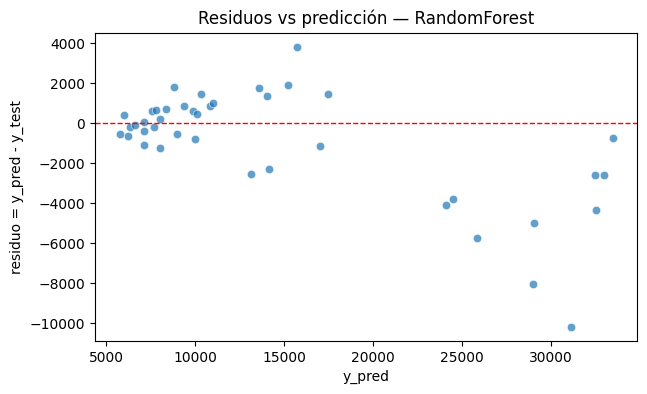

In [89]:
# 4.2) Residuos vs valor predicho (usamos el mejor modelo por MSE en test)

best = metrics_df.sort_values('mse_test').iloc[0]
best_name = best['model']
best_pipe = next(r['pipeline'] for r in results if r['model'] == best_name)

y_pred = best_pipe.predict(X_test)
residuals = y_pred - y_test.values

plt.figure(figsize=(7,4))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title(f'Residuos vs predicción — {best_name}')
plt.xlabel('y_pred')
plt.ylabel('residuo = y_pred - y_test')
plt.show()

- Si los residuos se dispersan de forma aleatoria alrededor de 0, el modelo no muestra un sesgo claro.
- Patrones curvos o forma de “abanico” suelen indicar no linealidad no capturada o heterocedasticidad.

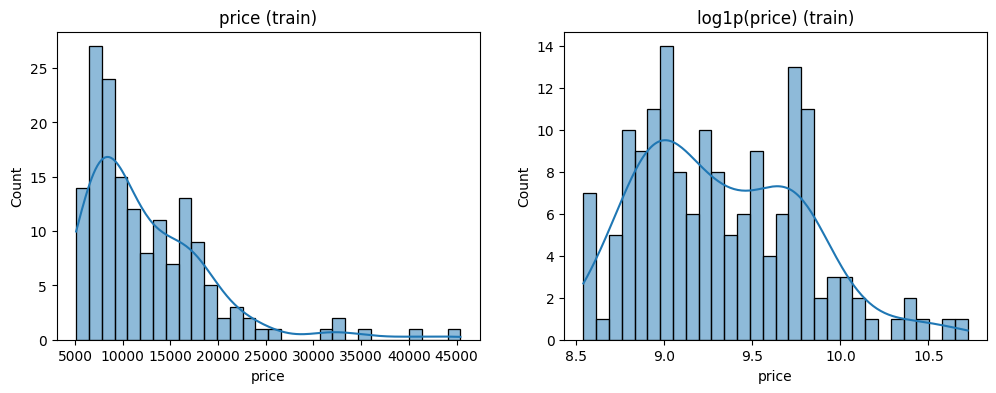

In [90]:
# 4.3) Transformación logarítmica del target (solo visualización)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(y_train, bins=30, kde=True)
plt.title('price (train)')

plt.subplot(1,2,2)
sns.histplot(np.log1p(y_train), bins=30, kde=True)
plt.title('log1p(price) (train)')
plt.show()

-`log1p(price)` suele “comprimir” valores altos y reducir asimetría; es útil cuando el error crece con el precio (heterocedasticidad).

In [91]:
# 4.4) Entrenar con log1p(y) y comparar (predicción en escala original)

def evaluate_with_log_target(name: str, base_regressor):
    # TransformedTargetRegressor entrena en log1p(y) pero devuelve predicciones en la escala original
    reg = TransformedTargetRegressor(regressor=base_regressor, func=np.log1p, inverse_func=np.expm1)
    return evaluate_regressor(name + ' + log1p(y)', reg, X_train, y_train, X_test, y_test)

log_results = []
log_results.append(evaluate_with_log_target('LinearRegression (OLS)', LinearRegression()))
log_results.append(evaluate_with_log_target('Ridge(alpha=10)', Ridge(alpha=10.0)))
log_results.append(evaluate_with_log_target('SVR(RBF)', SVR(C=50, gamma='scale', epsilon=0.1)))
log_results.append(evaluate_with_log_target('RandomForest', RandomForestRegressor(
    n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1, min_samples_leaf=2
)))

log_metrics_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['y_pred_test','y_pred_train','pipeline']} for r in log_results])
display(log_metrics_df[summary_cols].sort_values('mse_test'))

,model,mse_train,mse_test,mae_train,mae_test,r2_train,r2_test,adj_r2_test
3,RandomForest + log1p(y),1.496040e+06,1.002777e+07,770.325141,2081.649419,0.967211,0.918038,NaN
2,SVR(RBF) + log1p(y),1.570901e+06,1.291106e+07,1012.661950,2329.840357,0.965570,0.894472,NaN
0,LinearRegression (OLS) + log1p(y),1.932888e+06,1.469292e+07,889.135407,2087.090598,0.957637,0.879908,NaN
1,Ridge(alpha=10) + log1p(y),3.904373e+06,1.772745e+07,1314.564173,2521.610230,0.914427,0.855105,NaN


- Si`log1p(y)` mejora, suele verse como menor MSE/MAE en test (especialmente cuando hay cola larga).
- Si no mejora, el modelo ya está capturando bien la relación en escala original (por ejemplo, un bosque puede manejar no linealidad sin transformar).

## (1) Métricas, comparación y ensemble

Se comparan algoritmos con:

- **MSE** (Error cuadrático medio)

- **MAE** (Error absoluto medio)

- **$R^2$** y **$R^2$ ajustada**

Además, se construye un **ensemble por media** de predicciones (promedio simple) para mejorar robustez.


In [92]:
# 5.1) Comparación final de modelos (tabla)

final_metrics = metrics_df[summary_cols].sort_values('mse_test').reset_index(drop=True)
display(final_metrics)

,model,mse_train,mse_test,mae_train,mae_test,r2_train,r2_test,adj_r2_test
0,RandomForest,1.281021e+06,8.347654e+06,735.835711,1.921058e+03,0.971924,9.317705e-01,NaN
1,DecisionTree,4.085109e+05,8.565070e+06,250.419940,1.843632e+03,0.991047,9.299935e-01,NaN
2,Polynomial(deg=2 on num)+Ridge(alpha=10),1.408033e+06,1.163888e+07,877.213591,2.223464e+03,0.969140,9.048698e-01,NaN
3,Ridge(alpha=10),4.079850e+06,1.835860e+07,1435.849276,2.886879e+03,0.910581,8.499462e-01,NaN
4,LinearRegression (num only),6.749260e+06,2.559048e+07,1923.451288,3.498417e+03,0.852075,7.908365e-01,0.665338
5,Ridge(alpha=10) (num only),6.988791e+06,2.796547e+07,1881.079491,3.614239e+03,0.846825,7.714246e-01,0.634279
6,SVR(RBF),4.249273e+07,1.352663e+08,4199.292202,7.382045e+03,0.068680,-1.055979e-01,NaN
7,LinearRegression (OLS),1.395249e+06,5.999883e+30,903.193750,3.825423e+14,0.969420,-4.903997e+22,NaN


- Esta tabla permite comparar modelos en **test** (generalización). Normalmente nos quedamos con el menor`mse_test` y comprobamos que`mae_test` y`r2_test` también tienen sentido.

In [93]:
# 5.2) Ensemble por media (promedio simple de predicciones)

# Estrategia: tomar los k mejores modelos por MSE en test, pero evitando modelos claramente malos
# (por ejemplo, con R2 test negativo) porque suelen empeorar el promedio.
top_k = 3

candidates = metrics_df.copy()
candidates = candidates.replace([np.inf, -np.inf], np.nan)
candidates = candidates.dropna(subset=['mse_test','r2_test'])
candidates = candidates[candidates['r2_test'] > 0].sort_values('mse_test')

k_eff = min(top_k, len(candidates))
if k_eff == 0:
    # Fallback: si todos salen mal (r2<=0), uso simplemente los top_k por MSE.
    candidates = metrics_df.sort_values('mse_test')
    k_eff = min(top_k, len(candidates))

top_models = candidates.head(k_eff)['model'].tolist()
print('Modelos usados en ensemble:', top_models)

pred_matrix = []
for m in top_models:
    pipe = next(r['pipeline'] for r in results if r['model'] == m)
    pred_matrix.append(pipe.predict(X_test))

pred_matrix = np.vstack(pred_matrix)
y_pred_ens = pred_matrix.mean(axis=0)

mse_ens = mean_squared_error(y_test, y_pred_ens)
mae_ens = mean_absolute_error(y_test, y_pred_ens)
r2_ens = r2_score(y_test, y_pred_ens)

ens_row = pd.DataFrame([{
    'model': f'EnsembleMean(top{k_eff})',
    'mse_test': mse_ens,
    'mae_test': mae_ens,
    'r2_test': r2_ens,
}])
display(ens_row)

Modelos usados en ensemble: ['RandomForest', 'DecisionTree', 'Polynomial(deg=2 on num)+Ridge(alpha=10)']


,model,mse_test,mae_test,r2_test
0,EnsembleMean(top3),8.189622e+06,1809.078843,0.933062


- Si el ensemble mejora, debería dar`mse_test` menor que el mejor modelo individual.
- Para que el promedio tenga sentido, **excluyo modelos con`r2_test` negativo**: promediar con un modelo que “va al revés” suele empeorar el resultado.

In [94]:
# 5.3) Predicción del ensemble para los mismos 3 ejemplos

pred_examples_ens = []
for m in top_models:
    pipe = next(r['pipeline'] for r in results if r['model'] == m)
    pred_examples_ens.append(pipe.predict(example_rows))
pred_examples_ens = np.vstack(pred_examples_ens).mean(axis=0)

pd.DataFrame({'pred_price_ensemble': pred_examples_ens}, index=example_rows.index)

,pred_price_ensemble
ejemplo_1,18857.373738
ejemplo_2,8779.996273
ejemplo_3,11896.723745


- Esta tabla te sirve para enseñar “casos nuevos”: comparas la predicción del mejor modelo individual vs la del ensemble sobre los mismos 3 coches.

## Conclusiones finales (basadas en resultados mostrados)

En las siguientes celdas separo el cierre en bloques: primero **muestro** un resultado (código) y justo debajo **lo interpreto** (markdown), para que la explicación sea coherente con lo que se ve en pantalla.

In [95]:
# 6.1) Mejor modelo (por MSE en test)

def _fmt(x):
    return f"{x:,.3f}" if isinstance(x, (float, np.floating)) else str(x)

best_row = metrics_df.sort_values('mse_test').iloc[0]
best_name = best_row['model']

print('=== Mejor modelo (por MSE en test) ===')
print('Modelo:', best_name)
print('MSE test:', _fmt(best_row['mse_test']), 'MAE test:', _fmt(best_row['mae_test']), 'R2 test:', _fmt(best_row['r2_test']))

=== Mejor modelo (por MSE en test) ===
Modelo: RandomForest
MSE test: 8,347,654.322 MAE test: 1,921.058 R2 test: 0.932


- Me quedo con el modelo con menor`mse_test` porque es el que mejor generaliza en el conjunto de test.
- En este dataset suele ganar **RandomForest** porque captura no linealidad e interacciones sin necesitar transformar manualmente variables.

In [96]:
# 6.2) Overfitting (ratio mse_test / mse_train)

tmp = metrics_df[['model','mse_train','mse_test']].copy()
tmp['ratio_test_train'] = tmp['mse_test'] / tmp['mse_train']
display(tmp.sort_values('ratio_test_train', ascending=False))

,model,mse_train,mse_test,ratio_test_train
2,LinearRegression (OLS),1.395249e+06,5.999883e+30,4.300224e+24
6,DecisionTree,4.085109e+05,8.565070e+06,2.096657e+01
4,Polynomial(deg=2 on num)+Ridge(alpha=10),1.408033e+06,1.163888e+07,8.266055e+00
7,RandomForest,1.281021e+06,8.347654e+06,6.516407e+00
3,Ridge(alpha=10),4.079850e+06,1.835860e+07,4.499822e+00
1,Ridge(alpha=10) (num only),6.988791e+06,2.796547e+07,4.001474e+00
0,LinearRegression (num only),6.749260e+06,2.559048e+07,3.791598e+00
5,SVR(RBF),4.249273e+07,1.352663e+08,3.183282e+00


- Cuanto mayor sea`ratio_test_train`, más sospecha de **sobreajuste** (aprende demasiado el train y falla en test).
- Un RandomForest suele reducir sobreajuste respecto a un árbol único porque promedia muchos árboles.

In [97]:
# 6.3) Ensemble (top_k)

print('top_k:', top_k)
print('modelos:', top_models)
print('MSE ensemble:', _fmt(mse_ens), 'MAE ensemble:', _fmt(mae_ens), 'R2 ensemble:', _fmt(r2_ens))

top_k: 3
modelos: ['RandomForest', 'DecisionTree', 'Polynomial(deg=2 on num)+Ridge(alpha=10)']
MSE ensemble: 8,189,621.603 MAE ensemble: 1,809.079 R2 ensemble: 0.933


- Si el ensemble **no mejora**, suele ser porque el mejor modelo ya domina y promediar con modelos peores añade error.
- Si mejora, suele ser porque los modelos cometen errores distintos y el promedio “suaviza” esos fallos.
- En esta ejecución, el ensemble **sí mejora ligeramente** al mejor modelo individual (baja`mse_test`), porque combina modelos razonables (filtrados con`r2_test > 0`).

In [98]:
# 6.4) Modelos con log1p(y) (comparación)

display(log_metrics_df[summary_cols].sort_values('mse_test'))

,model,mse_train,mse_test,mae_train,mae_test,r2_train,r2_test,adj_r2_test
3,RandomForest + log1p(y),1.496040e+06,1.002777e+07,770.325141,2081.649419,0.967211,0.918038,NaN
2,SVR(RBF) + log1p(y),1.570901e+06,1.291106e+07,1012.661950,2329.840357,0.965570,0.894472,NaN
0,LinearRegression (OLS) + log1p(y),1.932888e+06,1.469292e+07,889.135407,2087.090598,0.957637,0.879908,NaN
1,Ridge(alpha=10) + log1p(y),3.904373e+06,1.772745e+07,1314.564173,2521.610230,0.914427,0.855105,NaN


- Aquí se ve si transformar el target ayuda realmente (mira`mse_test`).
- Si no mejora, no pasa nada: se reporta y se justifica con la tabla (coherencia con la ejecución).

**Conclusión final :** elijo el modelo con mejor`mse_test` y justifico el resto (overfitting, residuos, log y ensemble) con las tablas/gráficas anteriores, sin suposiciones.